In [1]:
import os
import sys
from textwrap import wrap
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import json
import pandas as pd

os.chdir("/home/kaariaa3/mscthesis/")
sys.path.append("./src/")  # Add module directory to path

from utils.helpers import parse_output

from utils.constants import DEFAULT_AUGMENT_RESULT

from utils.prompts import (
    JUDGE_SYSTEM_PROMPT,
    JUDGE_TEMPLATE,
    AUGMENT_SYSTEM_PROMPT,
    AUGMENT_TEMPLATE,
)

def wrap_text(text, num_chars):
    return '\n'.join(wrap(text, num_chars))

In [2]:
LABELS = ["yes", "no"] # Labels per column
EVAL_COLS = ['The exercise description matched the selected theme (Yes/Partially/No)',
       'The exercise description matched the selected topic (Yes/Partially/No)',
            "Included concepts that were too advanced (Yes/No)\n"]
PRED_COLS = ['augmentedProblemDescription', 'augmentedExampleSolution']

def find_str_between(text, start, end):
    s = text.find(start) + len(start)
    e = text.find(end, s)

    return text[s:e]

def plot_distributions(df, axes, labels=LABELS, cols=EVAL_COLS):
    fig = axes[0].figure

    for i, col in enumerate(cols):
        sns.countplot(x=df[col], order=labels, ax=axes[i])
        axes[i].set_title(wrap_text(f"{col.upper()}", 20))
        axes[i].set_xlabel("")

    return fig, axes


def row_to_str(row):
    
    return "Theme: " + row["theme"] + "\n" \
        + "Topic: " + row["topic"] + "\n" \
        + "Concept: " + row["concept"] + "\n" \
        + "The exercise description matched the selected theme (Yes/No): " + row["The exercise description matched the selected theme (Yes/No)"] + "\n" \
        + "The exercise description matched the selected topic (Yes/No): " + row["The exercise description matched the selected topic (Yes/No)"] + "\n" \
        + "Included concepts that were too advanced (Yes/No): " + row["Included concepts that were too advanced (Yes/No)"] + "\n" \
        + "\n" \
        + "Problem description:\n" + row["problemDescription"] + "\n" \
        + "\n" \
        + "Example solution:\n" + row["exampleSolution"] + "\n"

In [3]:
# Load data
datapath = r"./outputs/results/batch_16653574_result.csv"
augmented_data = pd.read_csv(datapath, sep=";")
print("Length of dataset before postprocessing: " + str(len(augmented_data)))
#augmented_data.to_excel(datapath.split("/")[-1][:-4] + ".xlsx")

# Remove rows with 'partially' labels
mask_no_partially = (augmented_data[EVAL_COLS] != "partially").all(axis=1)
augmented_data = augmented_data[mask_no_partially]
print(f"Removed {list(mask_no_partially).count(False)} rows containing 'partially' labels.")

# Remove erroneous examples
mask_no_errors = (augmented_data[PRED_COLS] != "\"PARSE ERROR\"").all(axis=1)
augmented_data = augmented_data[mask_no_errors]
print(f"Removed {list(mask_no_errors).count(False)} rows containing parsing errors")

# Keep rows that adhere to the given theme and topic
#mask_theme_yes = augmented_data[EVAL_COLS[0]].eq("yes")
#mask_topic_yes = augmented_data[EVAL_COLS[1]].eq("yes")

# Keep rows that do not include too advanced concepts
#mask_concept_no = augmented_data[EVAL_COLS[-1]].eq("no")
#print("Count of rows dropped: " + str(list(mask_theme_yes).count(False) + list(mask_concept_no).count(False)))

augmented_data = augmented_data.reset_index()

# Description from JSON string to string
augmented_data[PRED_COLS[0]] = augmented_data[PRED_COLS[0]].map(lambda x: json.loads(x))

# Remove new lines from example solutions to align style with original examples
augmented_data[PRED_COLS[1]] = augmented_data[PRED_COLS[1]].map(lambda x: x.replace("\\n", ""))

print("Final length of augmented dataset: " + str(len(augmented_data)))

Length of dataset before postprocessing: 283
Removed 10 rows containing 'partially' labels.
Removed 11 rows containing parsing errors
Final length of augmented dataset: 262


In [4]:
# Same theme as original exercise
same_theme = augmented_data.apply(lambda row: find_str_between(row["prompt"], "Theme: ", "\n") == row["theme"], axis=1)
print("Number of rows with original having same theme: " + str(list(same_theme).count(True)))
same_theme_indices = augmented_data.index[same_theme]

# Same topic as original exercise
same_topic = augmented_data.apply(lambda row: find_str_between(row["prompt"], "Topic: ", "\n") == row["topic"], axis=1)
print("Number of rows with original having same topic: " + str(list(same_topic).count(True))) # Sanity check, no row should have same theme, topic generated

# Set non-faithful instances to real column
augmented_data["problemDescription"] = augmented_data["augmentedProblemDescription"]
augmented_data["exampleSolution"] = augmented_data["augmentedExampleSolution"]

# Set new ground truth labels
augmented_data[EVAL_COLS[0]] = same_theme.map(lambda x: "yes" if x == True else "no")
augmented_data[EVAL_COLS[1]] = same_topic.map(lambda x: "yes" if x == True else "no")
augmented_data[EVAL_COLS[2]] = "yes"

# Drop last three columns: prompt, augmentedProblemDescription, augmentedExampleSolution
augmented_data = augmented_data.iloc[:, :-3]

Number of rows with original having same theme: 16
Number of rows with original having same topic: 0


In [5]:
# Load original dataset
orig = r"./data/complete_dataset.csv"
original_dataset = pd.read_csv(orig, sep=";")

# Remove rows with label 'partially'
mask_no_partially = (original_dataset[EVAL_COLS] != "partially").all(axis=1)
print("Count of rows with 'partially' labels: " + str(list(mask_no_partially).count(False)))
pruned = original_dataset[mask_no_partially].reset_index()

concated_with_pruned = pd.concat([pruned, augmented_data], ignore_index=True).iloc[:,:-1]

Count of rows with 'partially' labels: 10


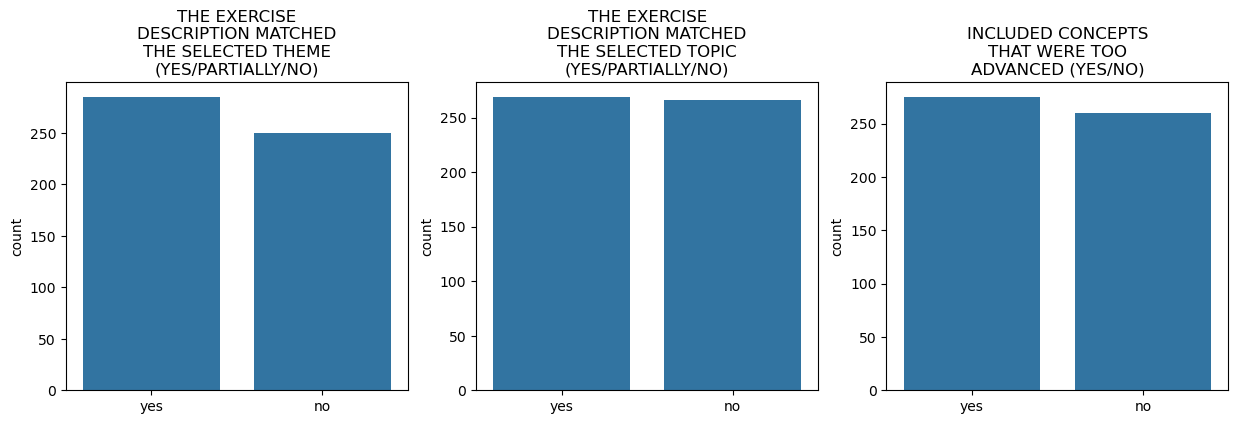

In [6]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))

plot_distributions(concated_with_pruned, ax)

plt.show()

In [14]:
# Rename columns
final_df = concated_with_pruned.rename(columns={col_name: col_name.replace("/Partially", "").replace("\n", "") for col_name in EVAL_COLS}, errors="raise")

# Take relevant columns
final_df = final_df[[
    "title",
    "problemDescription",
    "exampleSolution",
    "theme",
    "topic",
    "concept",
    "The exercise description matched the selected theme (Yes/No)", 
    "The exercise description matched the selected topic (Yes/No)",
    "Included concepts that were too advanced (Yes/No)"
]]

final_df.sample(frac=1, random_state=42, ignore_index=True).head()

,title,problemDescription,exampleSolution,theme,topic,concept,The exercise description matched the selected theme (Yes/No),The exercise description matched the selected topic (Yes/No),Included concepts that were too advanced (Yes/No)
0,Soap Hardness Level,"In soap making, the hardness level of soap is ...","{'code': ""import 'dart:io';\n\nmain() {\n pri...",handicrafts,soap making,logical operators,yes,yes,no
1,Calculate the total score in a game of Catan.,"In a game of Catan, players earn points by bui...","{'code': ""import 'dart:io'; main() { var se...",board games,Catan,variables,yes,yes,no
2,Chimamanda Ngozi Adichie's Books,Chimamanda Ngozi Adichie is a renowned Nigeria...,"{'code': ""import 'dart:io'; main() { print(...",literature,Chimamanda Ngozi Adichie,conditional statements,yes,yes,no
3,Christmas Carol!,Write a program that asks the user for their f...,"{'code': ""import 'dart:io';\nmain() {\n print...",Christmas,singing carols,user input,yes,yes,no
4,Calculating thread length for embroidery.,You are planning to start an embroidery projec...,"{'code': ""import 'dart:io'; main() { var le...",handicrafts,embroidery,arithmetics,yes,yes,no


In [17]:
# Pretty print to file for further analysis
#with open("./data/final_dataset_prettyprint.txt", "a") as f:
#    text = ("\n" + "-" * 100 + "\n").join([row_to_str(row) for (i, row) in final_df.iterrows()])
#    f.write(text)

In [18]:
final_df.to_csv("./data/final_dataset.csv", sep=";", index=False)

In [ ]:
# Stats
stats = final_df.columns[-3:]
columns = pd.MultiIndex.from_tuples([
    ("yes", "Count"),
    ("yes", "Percentage"),
    ("no", "Count"),
    ("no", "Percentage"),
])

len_df = len(final_df)
count_yes = final_df[stats].eq("yes").sum()
count_no = final_df[stats].eq("no").sum()

data = list(zip(
    count_yes, 100 * count_yes / len_df,
    count_no, 100 * count_no / len_df
))

df_stats = pd.DataFrame(data, index=stats, columns=columns)

print(
    df_stats.to_latex(float_format="%.1f")
    .replace("tabular}", "tabularx}{\\textwidth}", 1)
    .replace("tabular}", "tabularx}")
)

\begin{tabularx}{\textwidth}{lrrrr}
\toprule
 & \multicolumn{2}{r}{yes} & \multicolumn{2}{r}{no} \\
 & Count & Percentage & Count & Percentage \\
\midrule
The exercise description matched the selected theme (Yes/No) & 285 & 53.3 & 250 & 46.7 \\
The exercise description matched the selected topic (Yes/No) & 269 & 50.3 & 266 & 49.7 \\
Included concepts that were too advanced (Yes/No) & 275 & 51.4 & 260 & 48.6 \\
\bottomrule
\end{tabularx}

